# Прогнозирование цены подержанных автомобилей


Исследование цен автомобилей на основе работы по курсу «Методы машинного обучения», МИЭМ, 2026.

В этой версии представлены анализ данных, обработка пропусков и дубликатов, приведение torque к Nm и корреляционная матрица.


## Импорт библиотек, установка констант

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
from IPython.display import display

In [2]:
from pathlib import Path

# Сначала используем CSV из репозитория, затем — исходный источник.
data_candidates = [Path('data'), Path('../data')]
data_dir = next((p for p in data_candidates
                 if (p / 'cars_train.csv').is_file() and (p / 'cars_test.csv').is_file()), None)
CARS_TRAIN = (data_dir / 'cars_train.csv' if data_dir is not None else
              'https://raw.githubusercontent.com/evgpat/datasets/refs/heads/main/cars_train.csv')
CARS_TEST = (data_dir / 'cars_test.csv' if data_dir is not None else
             'https://raw.githubusercontent.com/evgpat/datasets/refs/heads/main/cars_test.csv')


In [3]:
RANDOM_STATE = 42

In [4]:
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## Подготовка данных


### Исследовательский анализ данных (EDA)





Выполним классические шаги EDA:

- Базовый EDA и обработка признаков
- Визуализации признаков и их анализ

### Простейший EDA и обработка признаков

In [5]:
df_train = pd.read_csv(CARS_TRAIN)
df_test = pd.read_csv(CARS_TEST)

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### Пропуски, дубликаты и профиль данных


In [6]:
# Зависимости: pandas, numpy, matplotlib, seaborn, scikit-learn,
# lightgbm, fg-data-profiling. Установите их перед запуском ноутбука.


In [7]:
from data_profiling import ProfileReport

print("Тренировочный датасет")
display(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print("Кол-во дубликатов =", df_train.duplicated().sum())
print("Тестовый датасет")
display(df_test.isnull().sum()[df_test.isnull().sum() > 0])
print("Кол-во дубликатов =", df_test.duplicated().sum())

ProfileReport(df_train).to_notebook_iframe()
ProfileReport(df_test).to_notebook_iframe()


mileage      202
engine       202
max_power    196
torque       203
seats        202
dtype: int64

mileage      19
engine       19
max_power    19
torque       19
seats        19
dtype: int64

Тренировочный датасет
Кол-во дубликатов = 985
Тестовый датасет
Кол-во дубликатов = 62


Render HTML: 100%|##########| 1/1 [00:00<00:00,  7.68it/s]


В исходном train — **6999 строк**, в test — **1000 строк**, в каждой выборке по 13 столбцов.

По сохранённым выводам `isnull().sum()`:
- Train: `mileage` — 202, `engine` — 202, `max_power` — 196, `torque` — 203, `seats` — 202. Всего **1005** пропущенных значений.
- Test: по 19 пропусков в каждом из этих пяти столбцов. Всего **95** пропущенных значений.

По `duplicated().sum()` обнаружено **985** полностью повторяющихся строк в train и **62** в test. Ниже удаляются только повторы в train по признакам без целевой переменной; это другой критерий дублирования. Test сохраняется без удаления строк.

Цена имеет правостороннюю асимметрию: средняя цена больше медианной. В train диапазон — от 29 999 до 10 000 000, в test — от 31 000 до 6 000 000 (в единицах исходного датасета).


### Описательные статистики


In [8]:
print("Статистики для трейна")
display(df_train.describe())
display(df_train.describe(include='object'))

print("Статистики для теста")
display(df_test.describe())
display(df_test.describe(include='object'))

,year,selling_price,km_driven,seats
count,6999.000000,6.999000e+03,6.999000e+03,6797.000000
mean,2013.818403,6.395152e+05,6.958462e+04,5.419008
std,4.053095,8.089419e+05,5.772400e+04,0.965767
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.700000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,6999,6999,6999,6999,6999,6797,6797,6803,6796
unique,1924,4,3,2,5,386,120,316,419
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,18.9 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
freq,116,3793,5826,6095,4587,197,885,330,468


,year,selling_price,km_driven,seats
count,1000.000000,1.000000e+03,1000.000000,981.000000
mean,2013.681000,6.179010e+05,71393.341000,5.410805
std,4.012149,7.585539e+05,48486.218662,0.919985
min,1995.000000,3.100000e+04,1303.000000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,9.000000


,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
count,1000,1000,1000,1000,1000,981,981,981,981
unique,621,4,3,2,5,237,88,182,226
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner,18.6 kmpl,1248 CC,74 bhp,200Nm@ 1750rpm
freq,15,534,837,877,623,23,116,43,57


Статистики для трейна
Статистики для теста


В train средняя цена составляет около 639 515, медианная — 450 000. В test средняя — около 617 901, медианная — 434 999.

Средние выше медиан: дорогие автомобили смещают среднее вверх. Сводные показатели train и test близки; сами по себе они не доказывают совпадение распределений.


### Удаление повторов по признакам в train


In [9]:
feature_cols_task3 = df_train.columns.drop('selling_price')
dup_mask = df_train.duplicated(subset=feature_cols_task3, keep=False)

print("Всего строк в группах дублей =", dup_mask.sum())
print("Повторных строк к удалению =", df_train.duplicated(subset=feature_cols_task3).sum())
print("Все дубликаты")
df_train[dup_mask].sort_values(by=list(feature_cols_task3))

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1703,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
6307,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73 kmpl,1968 CC,174.33 bhp,380Nm@ 1750-2500rpm,5.0
1836,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
6704,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22 kmpl,2967 CC,241.4 bhp,580Nm@ 1400-3250rpm,5.0
117,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01 kmpl,1968 CC,188 bhp,400nm@ 1750-3000rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5637,Volvo XC40 D4 Inscription BSIV,2019,3800000,20000,Diesel,Individual,Automatic,First Owner,18.0 kmpl,1969 CC,190 bhp,400Nm,5.0
5652,Volvo XC40 D4 Inscription BSIV,2019,3800000,20000,Diesel,Individual,Automatic,First Owner,18.0 kmpl,1969 CC,190 bhp,400Nm,5.0
5753,Volvo XC40 D4 Inscription BSIV,2019,3800000,20000,Diesel,Individual,Automatic,First Owner,18.0 kmpl,1969 CC,190 bhp,400Nm,5.0
5991,Volvo XC40 D4 Inscription BSIV,2019,3800000,20000,Diesel,Individual,Automatic,First Owner,18.0 kmpl,1969 CC,190 bhp,400Nm,5.0


Всего строк в группах дублей = 1799
Повторных строк к удалению = 1159
Все дубликаты


In [10]:
df_train = df_train.drop_duplicates(subset=feature_cols_task3, keep='first')    # Удалить, оставив первую строку
df_train = df_train.reset_index(drop=True)

assert df_train.duplicated(subset=feature_cols_task3).sum() == 0
assert df_train.index.equals(pd.RangeIndex(len(df_train)))

df_train.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0


### Преобразование строковых числовых признаков


In [11]:
df_train[['mileage', 'engine', 'max_power', 'torque']].head()

,mileage,engine,max_power,torque
0,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
3,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"
4,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm


### Приведение единиц крутящего момента

В столбце `torque` значения в `kgm` переводятся в ньютон-метры: **1 kgm = 9.80665 Nm**. Записи `Nm`/`nm` не требуют пересчёта. Затем сохраняется только числовое значение в Nm. Пропуски обрабатываются следующим шагом.


In [12]:
def df_quant_transform(df):
    df['mileage'] = df['mileage'].str.split().str[0].astype(float)
    df['engine'] = df['engine'].str.split().str[0].astype(float)
    df['max_power'] = df['max_power'].str.split().str[0]
    df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')
    df['max_torque_rpm'] = df['torque'].str.extract(r'(?:@|at)\s*([\d,]+)')
    df['max_torque_rpm'] = df['max_torque_rpm'].str.replace(',', '').astype(float)
    # Приводим крутящий момент к Nm до удаления единиц.
    # Встречаются форматы '22.4 kgm at ...' и '11.5@ ... (kgm@ rpm)'.
    torque_text = df['torque'].str.lower()
    torque_value = torque_text.str.extract(r'([\d.]+)')[0].astype(float)
    is_kgm = torque_text.str.contains(r'kg\s*m', regex=True, na=False)
    # 1 kgf·m (обозначение kgm в данных) = 9.80665 Nm.
    df['torque'] = torque_value.where(~is_kgm, torque_value * 9.80665)

In [13]:
df_quant_transform(df_train)
df_train[['mileage', 'engine', 'max_power', 'torque', 'max_torque_rpm']].head()

,mileage,engine,max_power,torque,max_torque_rpm
0,23.40,1248.0,74.00,190.000000,2000.0
1,21.14,1498.0,103.52,250.000000,1500.0
2,23.00,1396.0,90.00,219.668960,1750.0
3,16.10,1298.0,88.20,112.776475,4500.0
4,20.14,1197.0,81.86,113.750000,4000.0


In [14]:
df_quant_transform(df_test)
df_test[['mileage', 'engine', 'max_power', 'torque', 'max_torque_rpm']].head()

,mileage,engine,max_power,torque,max_torque_rpm
0,14.0,2498.0,112.0,260.0,1800.0
1,21.5,1497.0,108.5,260.0,1500.0
2,12.9,1799.0,130.0,172.0,4300.0
3,25.1,1498.0,98.6,200.0,1750.0
4,16.5,1172.0,65.0,96.0,3000.0


### Заполнение пропусков


In [15]:
numeric_cols_with_missing = [
    'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm'
]

mean_median_compare = pd.DataFrame({
    'mean': df_train[numeric_cols_with_missing].mean(),
    'median': df_train[numeric_cols_with_missing].median(),
})

mean_median_compare['mean_minus_median'] = (
    mean_median_compare['mean'] - mean_median_compare['median']
)

mean_median_compare['mean_to_median_ratio'] = (
    mean_median_compare['mean'] / mean_median_compare['median']
)

mean_median_compare

,mean,median,mean_minus_median,mean_to_median_ratio
mileage,19.432842,19.37,0.062842,1.003244
engine,1435.418111,1248.00,187.418111,1.150175
max_power,88.103070,81.86,6.243070,1.076265
torque,176.457455,160.00,16.457455,1.102859
seats,5.440750,5.00,0.440750,1.088150
max_torque_rpm,2682.528004,2000.00,682.528004,1.341264


In [16]:
df_train.isnull().sum()

name                0
year                0
selling_price       0
km_driven           0
fuel                0
seller_type         0
transmission        0
owner               0
mileage           186
engine            186
max_power         184
torque            187
seats             186
max_torque_rpm    198
dtype: int64

In [17]:
df_test.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage           19
engine            19
max_power         19
torque            19
seats             19
max_torque_rpm    23
dtype: int64

In [18]:
from sklearn.impute import SimpleImputer

numeric_cols_with_missing = [
    'mileage', 'engine', 'max_power', 'torque', 'seats', 'max_torque_rpm'
]

imputer = SimpleImputer(strategy='median')

df_train[numeric_cols_with_missing] = imputer.fit_transform(
    df_train[numeric_cols_with_missing]
)

df_test[numeric_cols_with_missing] = imputer.transform(
    df_test[numeric_cols_with_missing]
)

In [19]:
df_train.isnull().sum().sum()

np.int64(0)

In [20]:
df_test.isnull().sum().sum()

np.int64(0)

Пропуски заполняются медианами, рассчитанными только по train. Те же значения применяются к test.

Медиана менее чувствительна к экстремальным значениям, чем среднее. Заполнение средним также возможно, но в этой работе выбран более устойчивый вариант — медиана.


### Типы данных


In [21]:
df_train['engine'] = df_train['engine'].astype(int)
df_train['seats'] = df_train['seats'].astype(int)

df_test['engine'] = df_test['engine'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

print("Трейн")
display(df_train)
print("Тест")
display(df_test)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,max_torque_rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,190.000000,5,2000.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,250.000000,5,1500.0
2,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,219.668960,5,1750.0
3,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,112.776475,5,4500.0
4,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197,81.86,113.750000,5,4000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,Hyundai Santro Xing GLS,2008,120000,191000,Petrol,Individual,Manual,First Owner,17.92,1086,62.10,96.100000,5,3000.0
5836,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.90,998,67.10,90.000000,5,3500.0
5837,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197,82.85,113.700000,5,4000.0
5838,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493,110.00,235.359600,5,1900.0


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,max_torque_rpm
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.00,2498,112.00,260.00000,7,1800.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.50,1497,108.50,260.00000,5,1500.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.90,1799,130.00,172.00000,5,4300.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.10,1498,98.60,200.00000,5,1750.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.50,1172,65.00,96.00000,5,3000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Hyundai i10 Magna 1.1L,2008,250000,100000,Petrol,Individual,Manual,Second Owner,19.81,1086,68.05,99.04000,5,4500.0
996,Hyundai i20 2015-2017 Sportz 1.2,2017,440000,50000,Petrol,Individual,Manual,Second Owner,18.60,1197,81.83,114.70000,5,4000.0
997,Hyundai i20 Era Diesel,2009,340000,40000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,219.66896,5,1750.0
998,Hyundai i10 Asta,2012,350000,25000,Petrol,Individual,Manual,First Owner,20.36,1197,78.90,111.80000,5,4000.0


Трейн
Тест


`engine` и `seats` приведены к целому типу. Число мест принимает ограниченный набор значений, поэтому в следующих экспериментах `seats` рассматривается как категориальный признак.


### Визуализации и корреляция

Попарные диаграммы используются для сравнения распределений train и test и исследования связей признаков с ценой.


### Попарные распределения


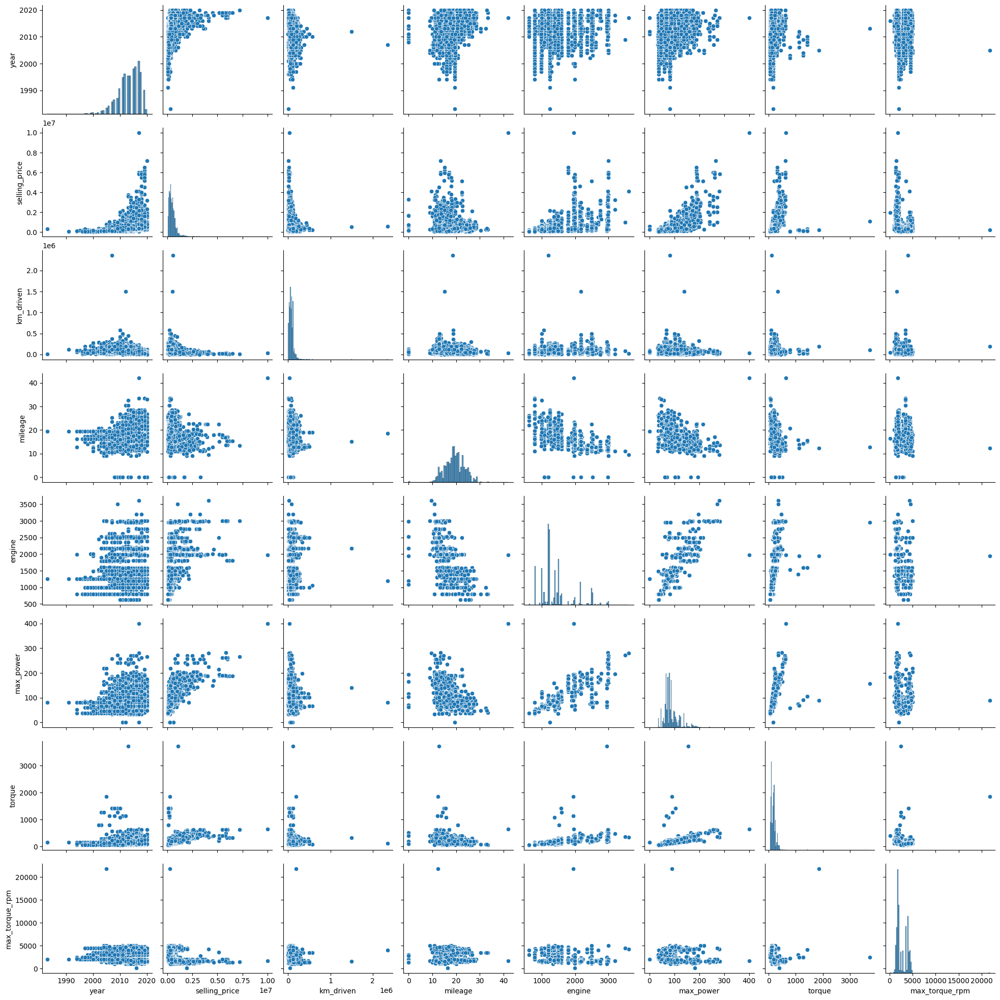

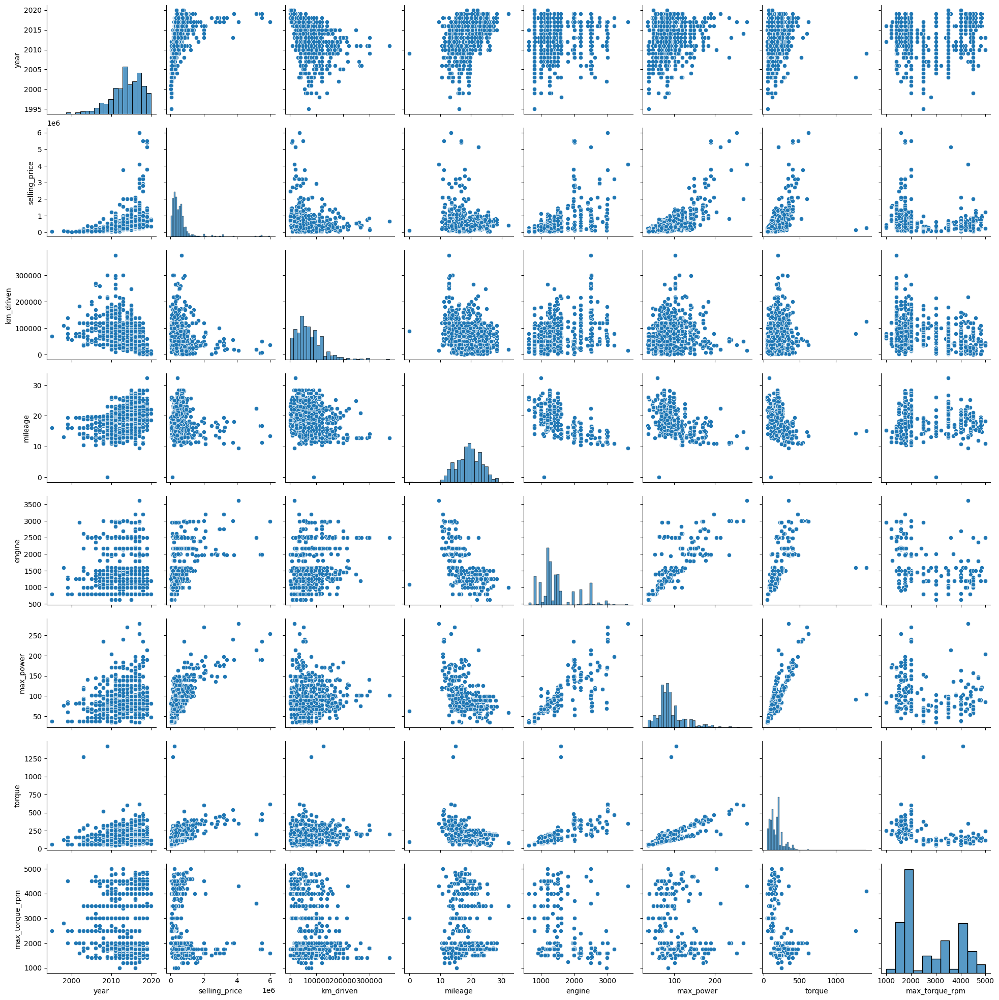

In [22]:
num_cols = ['year', 'selling_price', 'km_driven', 'mileage',
            'engine', 'max_power', 'torque', 'max_torque_rpm']

sns.pairplot(df_train[num_cols])
plt.show()

sns.pairplot(df_test[num_cols])
plt.show()

Связь признаков с selling_price:
- max_power и selling_price — есть положительная связь: чем мощнее — тем дороже
- engine и selling_price — аналогично, прослеживается положительная связь
- torque и selling_price — аналогично, прослеживается положительная связь
- km_driven и selling_price — связь слабая
- mileage и selling_price — слабая отрицательная связь

Гипотезы о корреляциях между признаками:
- engine и max_power — точки образуют наклонную линию,
  сильная положительная корреляция
- engine и torque — аналогично, сильная положительная связь
- max_power и torque — аналогично, сильная положительная связь
- mileage и engine — отрицательная связь:
  чем больше объём двигателя, тем меньше экономичность топлива

Похожими ли оказались совокупности при разделении на трейн и тест?
Распределения в целом похожи — те же связи между признаками сохраняются.
Однако в трейне и тесте может содержаться разные по экстремальности выбросы:
km_driven в трейн до примерно 2 500 000 против примерно 400 000 в тест,
selling_price в трейн до 10 000 000 против 6 000 000 в тест.

### Корреляционная матрица


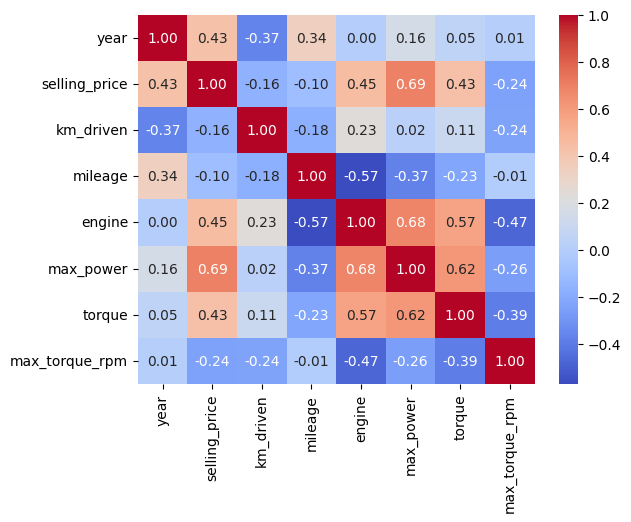

In [23]:
num_cols = ['year', 'selling_price', 'km_driven', 'mileage',
            'engine', 'max_power', 'torque', 'max_torque_rpm']

corr_matrix = df_train[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### Интерпретация корреляций

- `max_power` и `torque`: **0.616**.
- `max_power` и `engine`: **0.681**.
- `torque` и `engine`: **0.566**.
- `max_power` и `selling_price`: **0.693**.
- `year` и `km_driven`: **-0.369**.

Корреляция описывает связь в этой выборке, а не причинную зависимость.

### Интерпретация корреляций

- `max_power` и `torque`: **0.616**.
- `max_power` и `engine`: **0.681**.
- `torque` и `engine`: **0.566**.
- `max_power` и `selling_price`: **0.693**.
- `year` и `km_driven`: **-0.369**.

Корреляция описывает связь в этой выборке, а не причинную зависимость.